In [59]:
import torch

torch.manual_seed(42)


## 1 Создание нейронов и полносвязных слоев

1.1. Используя операции над матрицами и векторами из библиотеки `torch`, реализовать нейрон с заданными весами `weights` и `bias`. Прогнать вектор `inputs` через нейрон и вывести результат. 

In [60]:
class Neuron:
  def __init__(self, weights, bias):
    self.weights = weights
    self.bias = bias

  def forward(self, inputs):
    return inputs @ self.weights + self.bias


In [61]:
inputs = torch.tensor([1.0, 2.0, 3.0, 4.0])
weights = torch.tensor([-0.2, 0.3, -0.5, 0.7])
bias = 3.14

neuron = Neuron(weights, bias)
print(neuron.forward(inputs))


tensor(4.8400)


1.2 Используя операции над матрицами и векторами из библиотеки `torch`, реализовать полносвязный слой с заданными весами `weights` и `biases`. Прогнать вектор `inputs` через слой и вывести результат. 

In [62]:
class Linear:
  def __init__(self, weights, biases):
    self.weights = weights
    self.biases = biases

  def forward(self, inputs):
    return inputs @ self.weights + self.biases


In [63]:
inputs = torch.tensor([1.0, 2.0, 3.0, 4.0])
weights = torch.tensor([[-0.2, 0.3, -0.5, 0.7],
                        [0.5, -0.91, 0.26, -0.5],
                        [-0.26, -0.27, 0.17, 0.87]]).T

biases = torch.tensor([3.14, 2.71, 7.2])

layer = Linear(weights, biases)
print(layer.forward(inputs))


tensor([ 4.8400,  0.1700, 10.3900])


1.3 Реализовать полносвязный слой из __1.2__ таким образом, чтобы он мог принимать на вход матрицу (батч) с данными. Продемонстрировать работу.
Результатом прогона сквозь слой должна быть матрица размера `batch_size` x `n_neurons`.


In [64]:
inputs = torch.tensor([[1, 2, 3, 2.5],
                       [2, 5, -1, 2],
                       [-1.5, 2.7, 3.3, -0.8]], dtype=torch.float32)

print(layer.forward(inputs))


tensor([[ 3.7900,  0.9200,  9.0850],
        [ 6.1400, -2.1000,  6.9000],
        [ 2.0400,  0.7610,  6.7260]])


1.4 Используя операции над матрицами и векторами из библиотеки `torch`, реализовать полносвязный слой из `n_neurons` нейронов с `n_features` весами у каждого нейрона (инициализируются из стандартного нормального распределения). Прогнать вектор `inputs` через слой и вывести результат. Результатом прогона сквозь слой должна быть матрица размера `batch_size` x `n_neurons`.

In [65]:
class Linear:
  def __init__(self, n_features, n_neurons):
    self.weights = torch.randn(n_features, n_neurons)
    self.biases = torch.randn(n_neurons)

  def forward(self, inputs):
    return inputs @ self.weights + self.biases


1.5 Используя решение из __1.4__, создать 2 полносвязных слоя и пропустить матрицу `inputs` последовательно через эти два слоя. Количество нейронов в первом слое выбрать произвольно, количество нейронов во втором слое выбрать так, чтобы результатом прогона являлась матрица (3x7). 

In [66]:
inputs = torch.tensor([[1, 2, 3, 2.5],
                       [2, 5, -1, 2],
                       [-1.5, 2.7, 3.3, -0.8]], dtype=torch.float32)

layer1 = Linear(n_features=4, n_neurons=5)
out1 = layer1.forward(inputs)
print(out1.shape)

layer2 = Linear(n_features=5, n_neurons=7)
out2 = layer2.forward(out1)
print(out2.shape)


torch.Size([3, 5])
torch.Size([3, 7])


## 2 Создание функций активации

2.1 Используя операции над матрицами и векторами из библиотеки `torch`, реализовать функцию активации ReLU:

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/f4353f4e3e484130504049599d2e7b040793e1eb)

Создать матрицу размера (4,3), заполненную числами из стандартного нормального распределения, и проверить работоспособность функции активации.

In [67]:
class ReLU:
  def forward(self, inputs):
    return torch.clamp(inputs, min=0)


x = torch.randn(4, 3)
relu = ReLU()
print(x)
print(relu.forward(x))


tensor([[ 0.0274, -0.7916, -0.5601],
        [-0.9977, -0.9444, -0.7357],
        [-0.3638,  1.4364,  0.3744],
        [-0.5670,  0.0394,  1.7093]])
tensor([[0.0274, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 1.4364, 0.3744],
        [0.0000, 0.0394, 1.7093]])


2.2 Используя операции над матрицами и векторами из библиотеки `torch`, реализовать функцию активации softmax:

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/6d7500d980c313da83e4117da701bf7c8f1982f5)

Создать матрицу размера (4,3), заполненную числами из стандартного нормального распределения, и проверить работоспособность функции активации. Строки матрицы трактовать как выходы линейного слоя некоторого классификатора для 4 различных примеров.

In [68]:
class Softmax:
  def forward(self, inputs):
    shifted = inputs - torch.max(inputs, dim=1, keepdim=True).values
    exp_values = torch.exp(shifted)
    return exp_values / exp_values.sum(dim=1, keepdim=True)


x = torch.randn(4, 3)
softmax = Softmax()
probs = softmax.forward(x)
print(probs)
print(probs.sum(dim=1))


tensor([[0.1648, 0.2133, 0.6219],
        [0.2834, 0.5250, 0.1916],
        [0.1469, 0.7403, 0.1128],
        [0.2158, 0.4951, 0.2891]])
tensor([1., 1., 1., 1.])


2.3 Используя операции над матрицами и векторами из библиотеки `torch`, реализовать функцию активации ELU:

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/eb23becd37c3602c4838e53f532163279192e4fd)

Создать матрицу размера (4,3), заполненную числами из стандартного нормального распределения, и проверить работоспособность функции активации.

In [69]:
class ELU:
  def __init__(self, alpha):
    self.alpha = alpha

  def forward(self, inputs):
    return torch.where(inputs > 0, inputs, self.alpha * (torch.exp(inputs) - 1))


x = torch.randn(4, 3)
elu = ELU(alpha=1.0)
print(x)
print(elu.forward(x))


tensor([[ 1.0729, -1.7529, -0.9982],
        [ 0.1582, -1.6172,  0.6904],
        [ 0.9998, -2.5733, -0.7208],
        [-0.7698,  0.0366,  0.3688]])
tensor([[ 1.0729, -0.8267, -0.6314],
        [ 0.1582, -0.8015,  0.6904],
        [ 0.9998, -0.9237, -0.5136],
        [-0.5369,  0.0366,  0.3688]])


## 3 Создание функции потерь

3.1 Используя операции над матрицами и векторами из библиотеки `torch`, реализовать функцию потерь MSE:

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/e258221518869aa1c6561bb75b99476c4734108e)

Создать полносвязный слой с 1 нейроном, прогнать через него батч `inputs` и посчитать значение MSE, трактуя вектор `y` как вектор правильных ответов.

In [70]:
class MSELoss:
  def forward(self, y_pred, y_true):
    return torch.mean((y_pred - y_true) ** 2)


In [71]:
inputs = torch.tensor([[1, 2, 3, 2.5],
                       [2, 5, -1, 2],
                       [-1.5, 2.7, 3.3, -0.8]], dtype=torch.float32)

y = torch.tensor([2, 3, 4], dtype=torch.float32)

layer = Linear(n_features=4, n_neurons=1)
y_pred = layer.forward(inputs).squeeze(-1)

mse = MSELoss()
print(mse.forward(y_pred, y))


tensor(11.5246)


3.2 Используя операции над матрицами и векторами из библиотеки `torch`, реализовать функцию потерь Categorical Cross-Entropy:

<img src="https://i.ibb.co/93gy1dN/Screenshot-9.png" width="200">

Создать полносвязный слой с 3 нейронами и прогнать через него батч `inputs`. Полученный результат пропустить через функцию активации softmax. Посчитать значение CCE, трактуя вектор `y` как вектор правильных ответов.

In [72]:
class CategoricalCrossentropyLoss:
  def forward(self, y_pred, y_true):
    y_pred = torch.clamp(y_pred, 1e-7, 1 - 1e-7)
    sample_idx = torch.arange(y_pred.shape[0])
    correct_class_probs = y_pred[sample_idx, y_true]
    return -torch.mean(torch.log(correct_class_probs))


In [73]:
inputs = torch.tensor([[1, 2, 3, 2.5],
                        [2, 5, -1, 2],
                        [-1.5, 2.7, 3.3, -0.8]], dtype=torch.float32)
y = torch.tensor([1, 0, 0])

layer = Linear(n_features=4, n_neurons=3)
softmax = Softmax()
cce = CategoricalCrossentropyLoss()

logits = layer.forward(inputs)
probs = softmax.forward(logits)
print(cce.forward(probs, y))


tensor(3.4046)


3.3 Модифицировать 3.1, добавив L2-регуляризацию.

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/d92ca2429275bfdc0474523babbafe014ca8b580)


In [74]:
class MSELossL2:
  def __init__(self, lambda_):
    self.lambda_ = lambda_

  def data_loss(self, y_pred, y_true):
    return torch.mean((y_pred - y_true) ** 2)

  def reg_loss(self, layer):
    return self.lambda_ * torch.sum(layer.weights ** 2)

  def forward(self, y_pred, y_true, layer):
    return self.data_loss(y_pred, y_true) + self.reg_loss(layer)


## 4 Обратное распространение ошибки

4.1 Используя один нейрон и SGD (1 пример за шаг), решите задачу регрессии

In [75]:
from sklearn.datasets import make_regression

X, y, coef = make_regression(n_features=4, n_informative=4, coef=True, bias=0.5)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)


[Граф вычислений для этой задачи](https://i.ibb.co/2dhDxZx/photo-2021-02-15-17-18-04.jpg)

4.1.1 Реализуйте класс `SquaredLoss`


In [76]:
class SquaredLoss:
  def forward(self, y_pred, y_true):
    return (y_pred - y_true) ** 2

  def backward(self, y_pred, y_true):
    self.dinput = 2 * (y_pred - y_true)


4.1.2. Модифицируйте класс `Neuron` из __1.1__:

  1) Сделайте так, чтобы веса нейрона инициализировались из стандартного нормального распределения

  2) Реализуйте расчет градиента относительно весов `weights` и `bias`

In [77]:
class Neuron:
  def __init__(self, n_inputs):
    self.weights = torch.randn(n_inputs)
    self.bias = torch.randn(1).item()

  def forward(self, inputs):
    self.inputs = inputs
    return inputs @ self.weights + self.bias

  def backward(self, dvalue):
    # dvalue - значение производной, которое приходит нейрону от следующего слоя сети
    # в данном случае это будет значение df/dc (созданное методом backward у объекта SquaredLoss)
    self.dweights = dvalue * self.inputs
    self.dinput = dvalue * self.weights
    self.dbias = dvalue


4.1.3 Допишите цикл для настройки весов нейрона

[SGD](https://ru.wikipedia.org/wiki/%D0%A1%D1%82%D0%BE%D1%85%D0%B0%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8%D0%B9_%D0%B3%D1%80%D0%B0%D0%B4%D0%B8%D0%B5%D0%BD%D1%82%D0%BD%D1%8B%D0%B9_%D1%81%D0%BF%D1%83%D1%81%D0%BA)

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/dda3670f8a8996a0d3bf80856bb4a166cc8db6d4)

In [78]:
n_inputs = X.shape[1]
learning_rate = 0.1
n_epoch = 100

neuron = Neuron(n_inputs)
loss = SquaredLoss()

losses = []
for epoch in range(n_epoch):
  for x_example, y_example in zip(X, y):
    # forward pass
    y_pred = neuron.forward(x_example)
    curr_loss = loss.forward(y_pred, y_example)
    losses.append(curr_loss.item())

    # backprop
    loss.backward(y_pred, y_example)
    neuron.backward(loss.dinput)

    # шаг оптимизации для весов (weights и bias) нейрона
    neuron.weights -= learning_rate * neuron.dweights
    neuron.bias -= learning_rate * neuron.dbias

  if epoch % 20 == 0:
    print(f'epoch {epoch}: loss={curr_loss.item():.4f}')


epoch 0: loss=0.0026


epoch 20: loss=0.0000
epoch 40: loss=0.0000
epoch 60: loss=0.0000
epoch 80: loss=0.0000


4.2 Решите задачу 4.1, используя пакетный градиентный спуск

Вычисления для этой задачи: 
[1](https://i.ibb.co/rmtQT6P/photo-2021-02-15-18-00-43.jpg)
[2](https://i.ibb.co/NmCFVnQ/photo-2021-02-15-18-01-17.jpg)

4.1.1 Модифицируйте класс `MSELoss` из __3.1__, реализовав расчет производной относительно предыдущего слоя с учетом того, что теперь работа ведется с батчами, а не с индивидуальными примерами
 

In [79]:
class MSELoss:
  def forward(self, y_pred, y_true):
    return torch.mean((y_pred - y_true) ** 2)

  def backward(self, y_pred, y_true):
    self.dinput = 2 * (y_pred - y_true) / y_pred.numel()


4.2.2. Модифицируйте класс `Neuron` из __4.1.2__:

  1) Реализуйте метод `forward` таким образом, чтобы он мог принимать на вход матрицу (батч) с данными. 

  2) Реализуйте расчет градиента относительно весов `weights` и `bias` с учетом того, что теперь работа ведется с батчами, а не с индивидуальными примерами

In [80]:
class Neuron:
  def __init__(self, n_inputs):
    self.weights = torch.randn(n_inputs)
    self.bias = torch.randn(1).item()

  def forward(self, inputs):
    self.inputs = inputs
    return inputs @ self.weights + self.bias

  def backward(self, dvalue):
    # dvalue - значение градиента, которое приходит нейрону от следующего слоя сети
    # в данном случае это будет градиент L по y^ (созданный методом backward у объекта MSELoss)
    self.dweights = self.inputs.T @ dvalue
    self.dbias = dvalue.sum()


4.2.3 Допишите цикл для настройки весов нейрона

In [81]:
n_inputs = X.shape[1]
learning_rate = 0.1
n_epoch = 100

neuron = Neuron(n_inputs)
loss = MSELoss()
losses = []

for epoch in range(n_epoch):
    # forward pass
    y_pred = neuron.forward(X)
    curr_loss = loss.forward(y_pred, y)
    losses.append(curr_loss.item())

    # backprop
    loss.backward(y_pred, y)
    neuron.backward(loss.dinput)

    # шаг оптимизации для весов (weights и bias) нейрона
    neuron.weights -= learning_rate * neuron.dweights
    neuron.bias -= learning_rate * neuron.dbias

    if epoch % 20 == 0:
      print(f'epoch {epoch}: loss={curr_loss.item():.4f}')


epoch 0: loss=10467.9951
epoch 20: loss=1.7713
epoch 40: loss=0.0013
epoch 60: loss=0.0000
epoch 80: loss=0.0000


4.3  Используя один полносвязный слой и  пакетный градиетный спуск, решите задачу регрессии из __4.1__

4.3.1 Модифицируйте класс `Linear` из __1.4__. ([вычисление градиентов](https://i.ibb.co/kgVR6m6/photo-2021-02-15-21-30-28.jpg))

In [82]:
class Linear:
  def __init__(self, n_features, n_neurons):
    self.weights = torch.randn(n_features, n_neurons)
    self.biases = torch.randn(1, n_neurons)

  def forward(self, inputs):
    self.inputs = inputs
    self.output = inputs @ self.weights + self.biases
    return self.output

  def backward(self, dvalues):
    self.dweights = self.inputs.T @ dvalues
    self.dbiases = dvalues.sum(dim=0, keepdim=True)
    self.dinputs = dvalues @ self.weights.T


In [83]:
layer = Linear(n_features=X.shape[1], n_neurons=1)
loss = MSELoss()

learning_rate = 0.1
n_epoch = 100

for epoch in range(n_epoch):
  y_pred = layer.forward(X)
  curr_loss = loss.forward(y_pred, y.view(-1, 1))

  loss.backward(y_pred, y.view(-1, 1))
  layer.backward(loss.dinput)

  layer.weights -= learning_rate * layer.dweights
  layer.biases -= learning_rate * layer.dbiases

  if epoch % 20 == 0:
    print(f'epoch {epoch}: loss={curr_loss.item():.4f}')


epoch 0: loss=10418.2188
epoch 20: loss=1.8487
epoch 40: loss=0.0013
epoch 60: loss=0.0000
epoch 80: loss=0.0000


4.4 Используя наработки из 4, создайте нейросеть и решите задачу регрессии.

Предлагаемая архитектура:
1. Полносвязный слой с 10 нейронами
2. Активация ReLU
3. Полносвязный слой с 1 нейроном


In [84]:
X = torch.linspace(-1, 1, 100).view(-1, 1)
y = X.pow(2) + 0.2 * torch.rand(X.size())

In [85]:
class Activation_ReLU:
  def forward(self, inputs):
    self.inputs = inputs
    self.output = inputs.clip(min=0)
    return self.output

  def backward(self, dvalues):
    self.dinputs = dvalues.clone()
    self.dinputs[self.inputs <= 0] = 0

In [86]:
# создание компонентов сети
fc1 = Linear(n_features=1, n_neurons=10)
relu1 = Activation_ReLU()
fc2 = Linear(n_features=10, n_neurons=1)

loss = MSELoss()
lr = 0.02

# какие эпохи сохраняем для визуализации динамики
checkpoints = {0, 1, 5, 20, 50, 100, 200, 500, 1000, 1500, 2000}

ys = []
# сохранить предсказание до обучения
with torch.no_grad():
  ys.append(fc2.forward(relu1.forward(fc1.forward(X))).detach().clone())

for epoch in range(2001):
  # forward pass
  out1 = fc1.forward(X)
  out2 = relu1.forward(out1)
  out = fc2.forward(out2)

  data_loss = loss.forward(out, y)

  if epoch in checkpoints:
    print(f'epoch {epoch} mean loss {data_loss.item():.6f}')
    ys.append(out.detach().clone())

  # backprop
  loss.backward(out, y)
  fc2.backward(loss.dinput)
  relu1.backward(fc2.dinputs)
  fc1.backward(relu1.dinputs)

  # шаг оптимизации для fc1
  fc1.weights -= lr * fc1.dweights
  fc1.biases -= lr * fc1.dbiases

  # шаг оптимизации для fc2
  fc2.weights -= lr * fc2.dweights
  fc2.biases -= lr * fc2.dbiases


epoch 0 mean loss 14.533403
epoch 1 mean loss 4.849970
epoch 5 mean loss 0.295890
epoch 20 mean loss 0.015885
epoch 50 mean loss 0.007456
epoch 100 mean loss 0.006908
epoch 200 mean loss 0.006679
epoch 500 mean loss 0.006255
epoch 1000 mean loss 0.005785
epoch 1500 mean loss 0.005443
epoch 2000 mean loss 0.005201


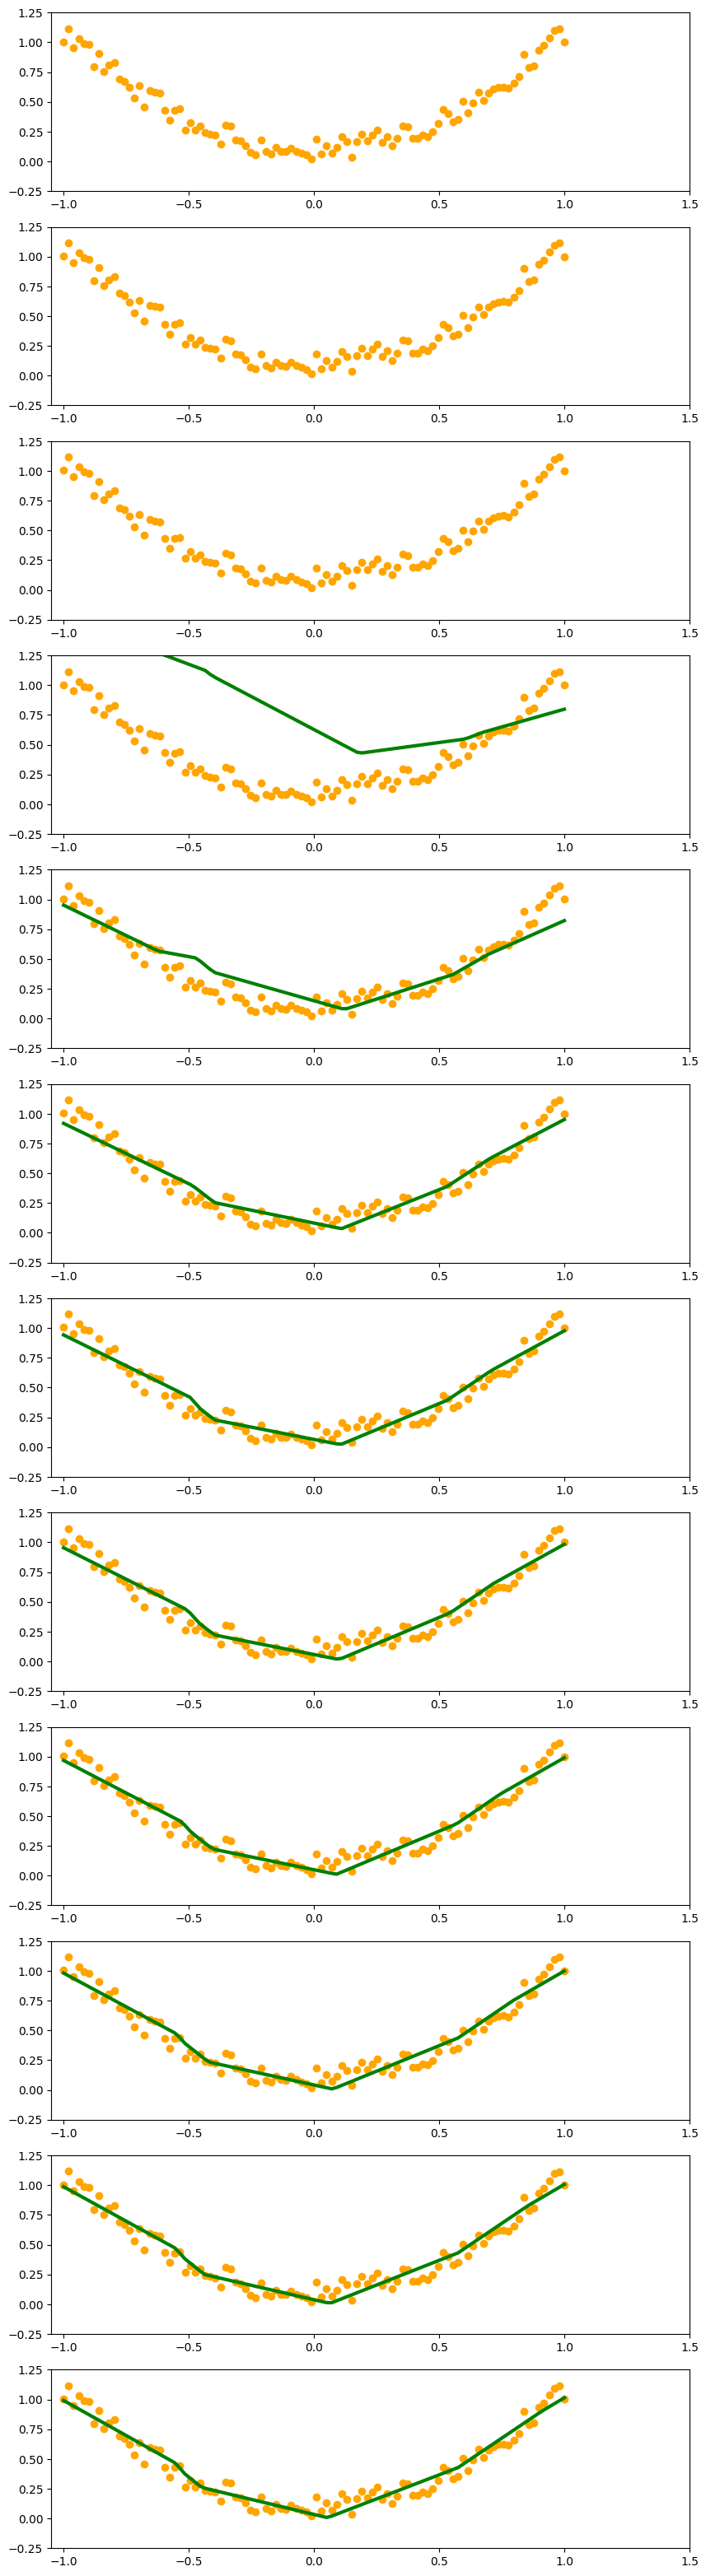

In [87]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(len(ys), 1, figsize=(10, 40))
for ax, y_ in zip(axs, ys):
  ax.scatter(X.numpy(), y.numpy(), color = "orange")
  ax.plot(X.numpy(), y_.numpy(), 'g-', lw=3)
  ax.set_xlim(-1.05, 1.5)
  ax.set_ylim(-0.25, 1.25)